# HYPOTHESIS 1: The gap perception between men and women is narrowing

Our hypothesis posits that the vocabulary used to describe men and women is converging, suggesting that over time, the discourse surrounding women has become increasingly similar to that of men (in terms of highlighted achievements, virtues, and social roles). To test this, we divided the dataset by year of death and fitted a year-specific TF-IDF vectorizer to create an adjusted vocabulary for each period. Subsequently, we generated two distinct centroid vectors (mean Document-Term Matrices) for men and women per year. Finally, we computed the cosine similarity between these vectors annually. This provides a longitudinal measure of the semantic proximity between gendered discourses, reflecting how society's values regarding men and women have evolved toward convergence.

NEEDD TO THINK IF THERE COULD BE SOME CONFOUNDER IN GENDER -> ORBITUARY IF WE ARE CONTROLLING FOR YEAR. IF AGE IS NOT (WE CAN ASSUME THAT YPPUNG PEOPLE DYING IS THE SAME MEN AND WOMEN)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression

Create the variable year so that we can know the death year directly.

In [2]:
df = pd.read_pickle("obituaries_lemma.pkl")
df['year'] = pd.to_datetime(df['date']).dt.year

Year 2001: Calculated similarity = 0.7736
Year 2002: Calculated similarity = 0.8233
Year 2003: Calculated similarity = 0.8249
Year 2004: Calculated similarity = 0.8070
Year 2005: Calculated similarity = 0.8081
Year 2006: Calculated similarity = 0.8128
Year 2007: Calculated similarity = 0.8105
Year 2008: Calculated similarity = 0.8215
Year 2009: Calculated similarity = 0.8354
Year 2010: Calculated similarity = 0.8482
Year 2011: Calculated similarity = 0.8486
Year 2012: Calculated similarity = 0.8649
Year 2013: Calculated similarity = 0.8672
Year 2014: Calculated similarity = 0.8760
Year 2015: Calculated similarity = 0.8768
Year 2016: Calculated similarity = 0.8869
Year 2017: Calculated similarity = 0.8717
Year 2018: Calculated similarity = 0.8815
Year 2019: Calculated similarity = 0.8665
Year 2020: Calculated similarity = 0.8718
Year 2021: Calculated similarity = 0.8685
Year 2022: Calculated similarity = 0.8634
Year 2023: Calculated similarity = 0.8720
Year 2024: Calculated similarity =

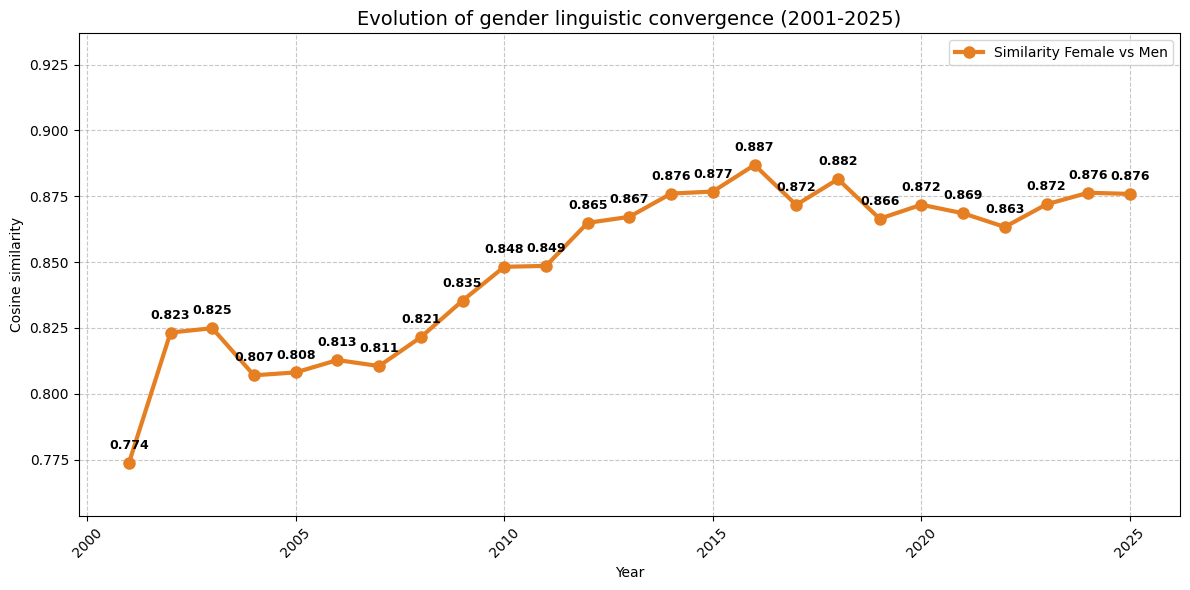

In [3]:
years = list(range(2001, 2026))
similarity_results = []


for i in years:
    
    df_year = df[df['year'] == i]
    text_m = df_year[df_year['gender'] == 'M']['text_clean']
    text_f = df_year[df_year['gender'] == 'F']['text_clean']
    
    if len(text_m) > 0 and len(text_f) > 0:
        # We create an specific TF-IDF for this year 
        vectorizer = TfidfVectorizer(max_df=0.4, min_df=2)
        vectorizer.fit(df_year['text_clean'])
        
        # We transfirm all the texts, and then create the "Mean Vector" for each gender. 
        tfidf_m = vectorizer.transform(text_m).mean(axis=0)
        tfidf_f = vectorizer.transform(text_f).mean(axis=0)
        
        # We compute the cosine similarity
        sim = cosine_similarity(np.asarray(tfidf_m), np.asarray(tfidf_f))[0][0]
        
        similarity_results.append({
            'Year': i,
            'Similarity': sim
        })
        print(f"Year {i}: Calculated similarity = {sim:.4f}")

# Ploting the results
df_res = pd.DataFrame(similarity_results)

if df_res.empty:
    print("Error: No data to plot.")
else:
    plt.figure(figsize=(12, 6))
    plt.plot(df_res['Year'], df_res['Similarity'], 
             marker='o', color='#e67e22', linewidth=3, markersize=8, label='Similarity Female vs Men')

    for i, row in df_res.iterrows():
        plt.annotate(f"{row['Similarity']:.3f}", 
                     (row['Year'], row['Similarity']), 
                     textcoords="offset points", 
                     xytext=(0,10), 
                     ha='center', 
                     fontweight='bold',
                     fontsize=9)

    plt.title('Evolution of gender linguistic convergence (2001-2025)', fontsize=14)
    plt.ylabel('Cosine similarity')
    plt.xlabel('Year')
    

    plt.ylim(df_res['Similarity'].min() - 0.02, df_res['Similarity'].max() + 0.05)
    
    plt.xticks(rotation=45) 
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

These results reveal a positive global trend that remains consistent across most yearly intervals, suggesting that the vocabularies used for men and women are progressively converging. To move beyond visual observation and ensure the statistical significance of this trend, we will perform a linear regression analysis on the similarity scores. This will allow us to quantify the rate of convergence and determine whether the observed narrowing of the linguistic gap is statistically robust or merely a product of annual variance.

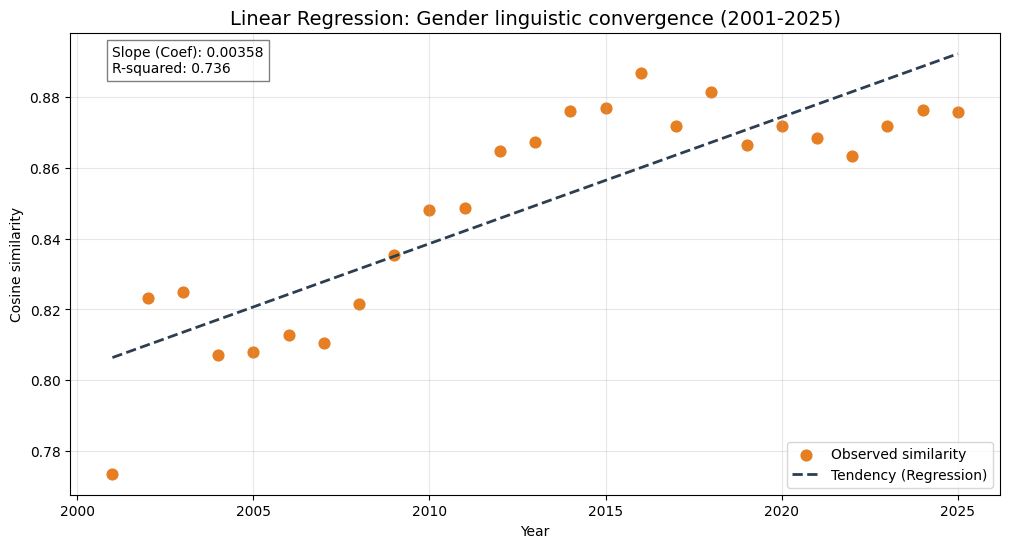

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.724
Method:                 Least Squares   F-statistic:                     64.11
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           4.23e-08
Time:                        18:31:33   Log-Likelihood:                 68.775
No. Observations:                  25   AIC:                            -133.5
Df Residuals:                      23   BIC:                            -131.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.3526      0.900     -7.062      0.0

In [4]:
X = np.array(df_res['Year']).reshape(-1, 1).astype(float)
y = df_res['Similarity'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
X_stat = sm.add_constant(X) 
model_stat = sm.OLS(y, X_stat).fit()

# Plotting the results
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='#e67e22', label='Observed similarity', s=60)
plt.plot(X, y_pred, color='#2c3e50', linestyle='--', linewidth=2, label='Tendency (Regression)')

plt.title('Linear Regression: Gender linguistic convergence (2001-2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Cosine similarity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.text(X.min(), y.max(), f"Slope (Coef): {model.coef_[0]:.5f}\nR-squared: {model_stat.rsquared:.3f}", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.show()

# Show the statistical summary
print(model_stat.summary())

The linear regression analysis provides conclusive evidence of a sustained linguistic convergence between the male and female datasets from 2001 to 2025. The model yields a coefficient of 0.0036 for the time variable ($x_1$), indicating that the cosine similarity between gendered discourses increases by an average of 0.36% every year. This positive slope is highly significant ($p < 0.001$), allowing us to reject the null hypothesis of linguistic stability with a high degree of confidence ($t = 8.007$).

Furthermore, the model exhibits a remarkably high R-squared value of 0.736, suggesting that the passage of time alone explains 73.6% of the variance in the similarity scores. This indicates that the convergence is not merely a series of isolated fluctuations, but a robust and predictable long-term trend. Although the Durbin-Watson statistic (0.676) suggests the presence of positive autocorrelation—which is expected in longitudinal linguistic data where vocabulary changes incrementally—the overall strength of the F-statistic (64.11) confirms the model's high explanatory power.

In conclusion, these results demonstrate a significant shift in social discourse: the traditional linguistic boundaries that once defined how men and women were described are steadily eroding, leading toward a more unified and neutral descriptive framework. These findings lead to our second hypothesis:


# HYPOTHESIS 2: The convergence of the perception gap between men and women is driven by the topics of Profession and Family.

To identify the specific areas driving this trend, we will analyze the convergence across four distinct thematic categories: Family, Professional, Religion, and Lifestyle. By constructing specialized lexicons for each domain, we aim to determine which of these dimensions show the highest rate of linguistic assimilation and which ones remain gender-segregated.

In [5]:
themes = {
    'Religion': set([
        'church', 'faith', 'god', 'jesus', 'christ', 'lord', 'pastor', 'reverend', 
        'priest', 'bible', 'scripture', 'catholic', 'baptist', 'methodist', 
        'christian', 'faithfully', 'heaven', 'blessed', 'prayer', 'pray', 
        'ministry', 'choir', 'spirit', 'spiritual', 'soul', 'devout', 'parish',
        'mass', 'vatican', 'amen', 'worship', 'congregation', 'clerical'
    ]),
    'Professional': set([
        'career', 'retired', 'worked', 'employed', 'professor', 'teacher', 
        'engineer', 'manager', 'director', 'business', 'company', 'university', 
        'degree', 'graduate', 'college', 'professional', 'owner', 'founder', 
        'department', 'industry', 'office', 'corporation', 'executive', 'nurse',
        'doctor', 'military', 'veteran', 'served', 'army', 'navy', 'position', 
        'engineer', 'management', 'job', 'electrician', 'employee','accountant',
        'consultant', 'officer', 'recruiter', 'administrator', 'vice president','supervisor'
    ]),
    'Family': set([
        'family', 'mother', 'father', 'son', 'daughter', 'brother', 'sister',
        'grandchild', 'grandchildren', 'grandson', 'granddaughter', 'grandmother',
        'grandfather', 'nana', 'papa', 'niece', 'nephew', 'cousin', 'aunt', 'uncle',
        'husband', 'wife', 'spouse', 'partner', 'loving', 'beloved', 'devoted',
        'survived', 'children', 'great-grandchildren', 'parent'
    ]),
    'Lifestyle': set([
        'travel', 'traveled', 'journey', 'adventure', 'hiking', 'sailing', 'golf', 
        'gardening', 'cooking', 'music', 'concerts', 'art', 'reading', 'books', 
        'nature', 'outdoors', 'animals', 'dogs', 'cats', 'pets', 'beach', 'lake',
        'traveling', 'passion', 'enjoyed', 'hobbies', 'photography', 'sports', 
        'fan', 'watching', 'food', 'wine', 'restaurant', 'club', 'fishing', 
        'camping', 'collector', 'painting', 'dance', 'dancing', 'volunteering'
    ])
}

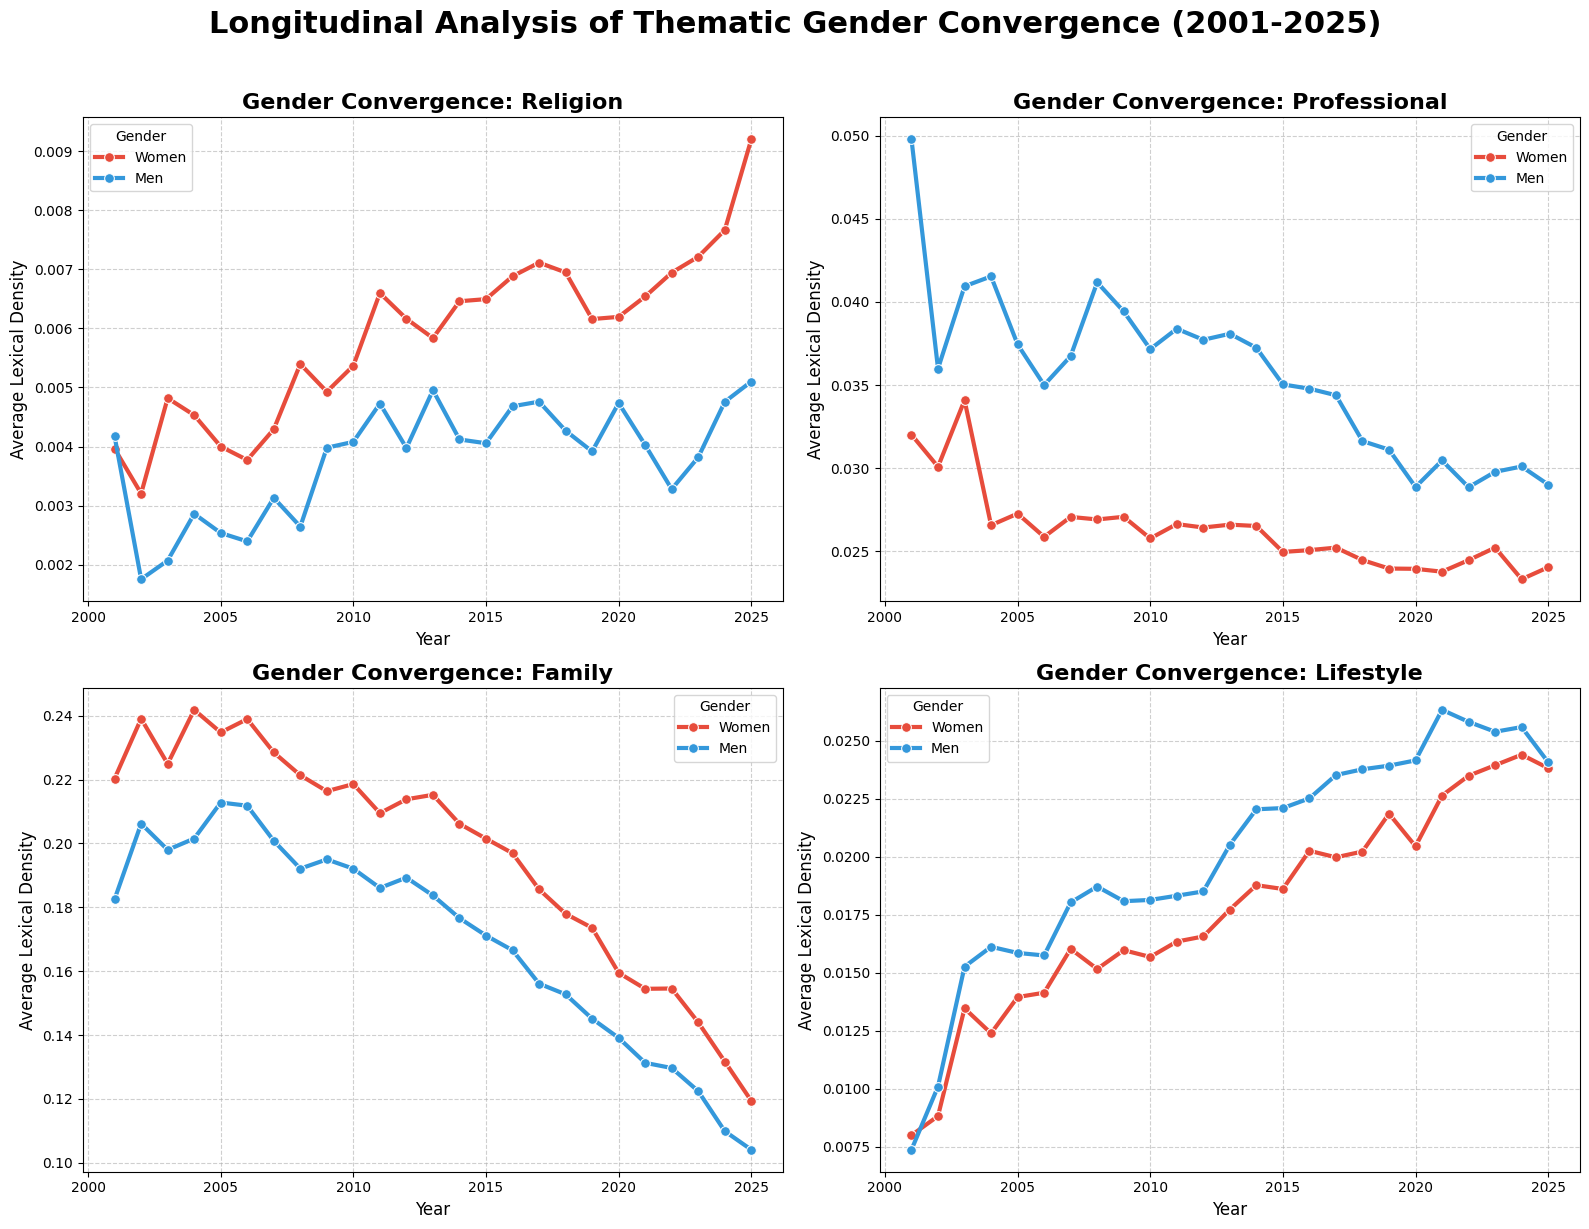

In [6]:

def get_density(text, word_set):
    if not isinstance(text, str): return 0
    tokens = text.lower().split()
    if not tokens: return 0
    return sum(1 for word in tokens if word in word_set) / len(tokens)

for name, word_set in themes.items():
    df[name] = df['text_clean'].apply(lambda x: get_density(x, word_set))



evolution = df.groupby(['year', 'gender'])[list(themes.keys())].mean().reset_index()
evolution['gender_label'] = evolution['gender'].map({'M': 'Men', 'F': 'Women'})
categories = list(themes.keys())
gender_colors = {'Men': '#3498db', 'Women': '#e74c3c'} 

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cat in enumerate(categories):
    sns.lineplot(
        data=evolution, 
        x='year', 
        y=cat, 
        hue='gender_label', 
        ax=axes[i], 
        palette=gender_colors,
        linewidth=3,
        marker='o',
        markersize=7
    )
    
    axes[i].set_title(f'Gender Convergence: {cat}', fontsize=16, fontweight='bold')
    axes[i].set_ylabel('Average Lexical Density', fontsize=12)
    axes[i].set_xlabel('Year', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(title='Gender', loc='best')

plt.suptitle('Longitudinal Analysis of Thematic Gender Convergence (2001-2025)', 
             fontsize=22, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


To empirically test the longitudinal evolution of the gender gap in the usage of specific thematic categories (Professional and Family, as are the ones that show the same pattern of convergence), we estimate a multiple linear regression model using Ordinary Least Squares (OLS). The objective of this specification is not merely to observe the isolated effects of gender and time, but to analyze their interaction in order to quantify how the lexical divergence between men and women has shifted over the 2001–2025 period. The fundamental equation of the model is specified as follows:

$$Y_i = \beta_0 + \beta_1 \mathit{Female}_i + \sum_{t=2002}^{2025} \gamma_t \mathit{Year}_{it} + \sum_{t=2002}^{2025} \delta_t (\mathit{Female}_i \times \mathit{Year}_{it}) + \epsilon_i$$

Where the parameters and variables are defined as:

- $Y_i$: The continuous dependent variable, representing the lexical density of a specific topic (i.e., the percentage of words associated with Professional or Family) in document $i$.

- $\mathit{Female}_i$: A binary (dummy) variable that takes the value of $1$ if the subject of document $i$ is female, and $0$ if male.

- $\mathit{Year}_{it}$: A vector of dummy variables for each year $t$ from 2002 to 2025. The year 2001 is omitted to avoid perfect multicollinearity (the dummy variable trap).

- $(\mathit{Female}_i \times \mathit{Year}_{it})$: The interaction terms between the female dummy and each specific year dummy.

- $\epsilon_i$: The idiosyncratic error term.

Whith this, the coefficients are estimates of:

- $\beta_0$ (Intercept): The expected value of the thematic density for the baseline reference group. In this design, the baseline group consists of male subjects in the starting year of the series (2001).

- $\beta_1$: Captures the difference between men and women in the baseline year (2001)

- $\gamma_t$: The main effect for each year, capturing the temporal evolution of the topic exclusively for the baseline group (males) relative to 2001.

- $\delta_t$ (Interaction coefficients): Measure the additional change in topic density for female texts relative to male texts in year $t$, compared to the baseline year.

This specification allows us to directly evaluate the hypothesis of thematic gender convergence. The absolute gender gap in any given year $t$ can be expressed as the sum of the baseline difference and the interaction term for that year ($\beta_1 + \delta_t$).

If historically male-dominated topics exhibit a negative baseline gap($\beta_1 < 0$), evidence of convergence would be reflected in positive and statistically significant interaction coefficients in subsequent years. Such coefficients indicate that the magnitude of the gender difference becomes progressively smaller over time ($|\beta_1 + \delta_t| < |\beta_1|$). By including these interaction terms, the model separates general time trends affecting both genders from gender-specific dynamics, allowing us to isolate the evolution of the linguistic gender gap.

In [7]:
df["gender_dummy"] = np.where(df["gender"] == "M", 0, 1)

for i in range(2001, 2026):
    df[f"{i}_dummy"] = (df["year"] == i).astype(int)
    df[f"{i}_F"] = df["gender_dummy"]*df[f"{i}_dummy"]


In [8]:
y = df["Professional"]
X_cols = ["gender_dummy"]
year_dummies = [f"{i}_dummy" for i in range(2002, 2026)]
X_cols.extend(year_dummies)
interaction_dummies = [f"{i}_F" for i in range(2002, 2026)]
X_cols.extend(interaction_dummies)
X = df[X_cols]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Professional   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     42.57
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:34:41   Log-Likelihood:             3.1660e+05
No. Observations:              215564   AIC:                        -6.331e+05
Df Residuals:                  215514   BIC:                        -6.326e+05
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0498      0.004     12.544   

The results of the OLS regression modeling the evolution of the “Professional” topic density between 2001 and 2025 support our hypothesis for professional language use:

In the baseline year (2001), there is a clear and statistically significant gender gap. The coefficient for the gender dummy is −0.0178 (p = 0.001), indicating that texts associated with female subjects contain a lower density of professional-related vocabulary compared to texts associated with male subjects (the reference group).

The interaction terms between the female dummy and year capture how this gap changes over time. All interaction coefficients are positive, meaning that in each year after 2001 the gender gap is smaller than in the baseline year. In other words, female texts gradually move closer to male texts in their use of professional-related language.

Moreover, these interaction coefficients generally show an upward trend over time. Early years have smaller positive effects (around 0.002–0.012), while more recent years show slightly larger values (up to ~0.013). Although there are minor year-to-year fluctuations, the overall pattern demonstrates a gradual and persistent convergence in professional language use between genders.

By the final year of the sample (2025), the interaction coefficient reaches 0.0128 (p = 0.025). When combined with the baseline gender effect (−0.0178), the remaining gap is reduced to approximately −0.005 percentage points—a very small difference.

In [9]:
y_fam = df["Family"]
X_cols = ["gender_dummy"]
year_dummies = [f"{i}_dummy" for i in range(2002, 2026)]
X_cols.extend(year_dummies)
interaction_dummies = [f"{i}_F" for i in range(2002, 2026)]
X_cols.extend(interaction_dummies)
X = df[X_cols]

X = sm.add_constant(X)
model_fam = sm.OLS(y_fam, X).fit()
print(model_fam.summary())

                            OLS Regression Results                            
Dep. Variable:                 Family   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     161.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:35:15   Log-Likelihood:                 68133.
No. Observations:              215564   AIC:                        -1.362e+05
Df Residuals:                  215514   BIC:                        -1.357e+05
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1825      0.013     14.523   

The OLS regression results modeling the evolution of the “Family” topic density from 2001 to 2025 show a statistically significant baseline gender difference. In 2001, the coefficient for the gender dummy is +0.0378 (p = 0.032), indicating that texts about women initially contained a higher density of family-related vocabulary compared to texts about men (the reference group).

The interaction terms between gender and year reflect how this gap evolves over time. In contrast to the “Professional” topic, the interaction coefficients for “Family” are mostly small and not statistically significant until the early 2010s. However, starting from 2013 onwards, the interaction coefficients become increasingly negative, showing a clear trend toward convergence. This means that over these years, the initially higher family-topic density in female texts gradually diminishes relative to male texts.

For example, the gap remaining in 2013 is approximately 0.0316 (0.0378 − 0.0062), while by 2025 it decreases further to about 0.0153 (0.0378 − 0.0225). These figures illustrate a steady reduction of the gender difference, signaling a gradual convergence in the use of family-related language over time.